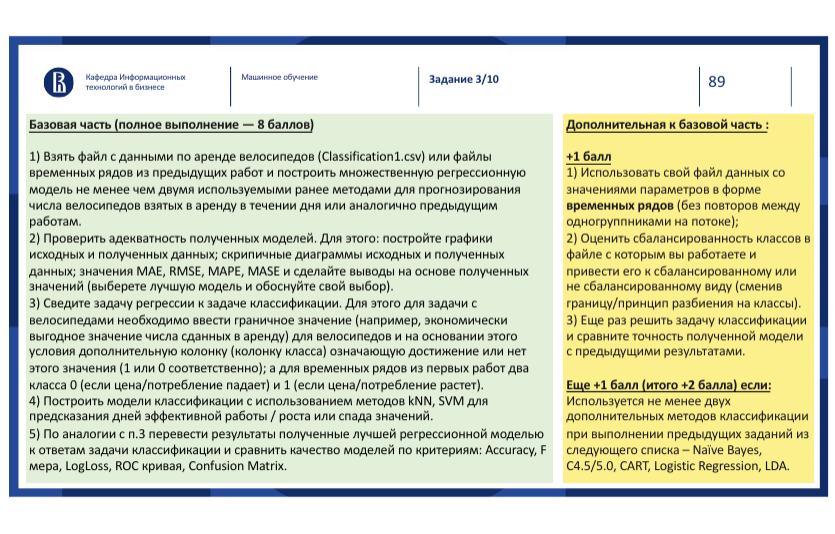

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, log_loss, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')



In [15]:

FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'
N_LAGS = 5
TEST_SIZE = 0.2

df = pd.read_csv(FILEPATH)
df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors='coerce')
df = df.dropna(subset=[DATETIME_COL, VALUE_COL]).sort_values(DATETIME_COL)

agg = {VALUE_COL: 'sum'}
if 'units' in df.columns:
    agg['units'] = 'sum'
for col in ['unit_price', 'housing_starts_index', 'lumber_price_index', 'mortgage_rate']:
    if col in df.columns:
        agg[col] = 'mean'

df_ts = df.groupby(DATETIME_COL).agg(agg).reset_index().sort_values(DATETIME_COL)

y_full = df_ts[VALUE_COL].values
dates = df_ts[DATETIME_COL].values
units_full = df_ts['units'].values if 'units' in df_ts.columns else None

In [ ]:

df_reg2 = pd.DataFrame({
    'y': y_full,
    'x1': np.arange(len(y_full)),
    'x2': units_full,
}).dropna().reset_index(drop=True)

df_lags = pd.DataFrame({'y': y_full})
for lag in range(1, 6):
    df_lags[f'lag_{lag}'] = df_lags['y'].shift(lag)
df_lags = df_lags.dropna().reset_index(drop=True)

feature_cols = [c for c in df_lags.columns if c != 'y']


#Для SWR
split_idx_2 = int(len(df_reg2) * 0.8)
train_2 = df_reg2.iloc[:split_idx_2]
test_2 = df_reg2.iloc[split_idx_2:]

X_train_2 = train_2[['x1', 'x2']].values
X_test_2 = test_2[['x1', 'x2']].values
y_train_2 = train_2['y'].values
y_test_2 = test_2['y'].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train_2)
X_test_s = scaler_X.transform(X_test_2)

#Для PLS
split_idx_lasso = int(len(df_ts) * 0.8)

train_pls = df_ts.iloc[:split_idx_lasso]
test_pls = df_ts.iloc[split_idx_lasso:]

X_train_pls = train_pls[feature_cols].values
y_train_pls = train_pls['y'].values
X_test_pls = test_pls[feature_cols].values
y_test_pls = test_pls['y'].values

scaler_l = StandardScaler()
X_train_l_pls = scaler_l.fit_transform(X_train_pls)
X_test_l_pls = scaler_l.transform(X_test_pls)


KeyError: "None of [Index(['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5'], dtype='str')] are in the [columns]"

МНК                  MAE=100,847 RMSE=127,938 MAPE=6.70% MASE=0.634 R2=0.9836
SVR                  MAE=232,894 RMSE=268,150 MAPE=15.10% MASE=1.465 R2=0.9280
Lasso                MAE=100,848 RMSE=127,938 MAPE=6.70% MASE=0.634 R2=0.9836

Лучшая регрессионная модель по RMSE: МНК


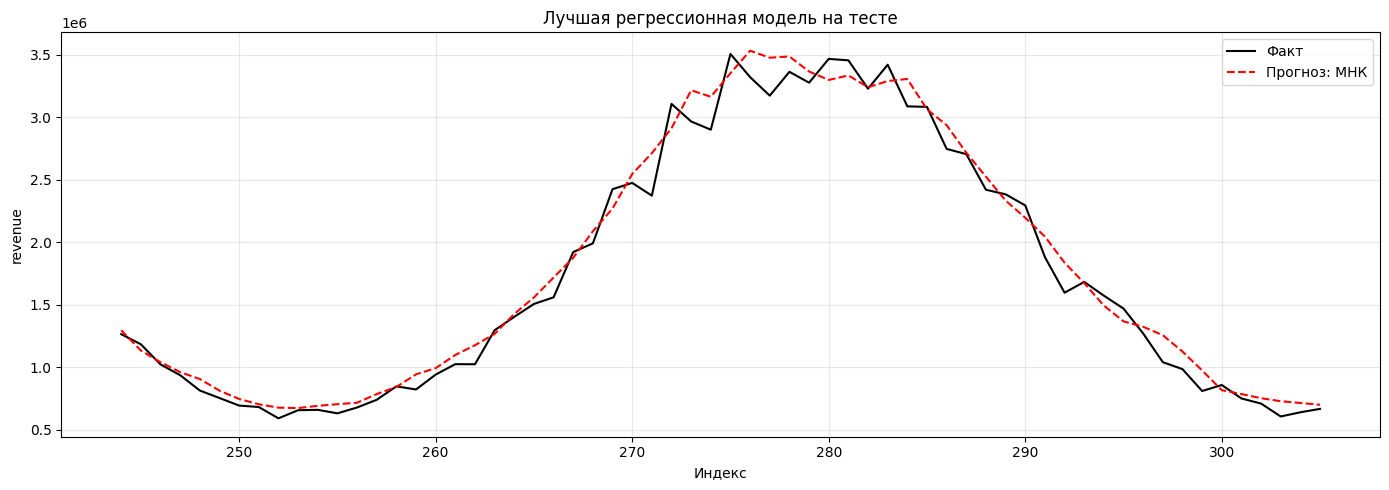

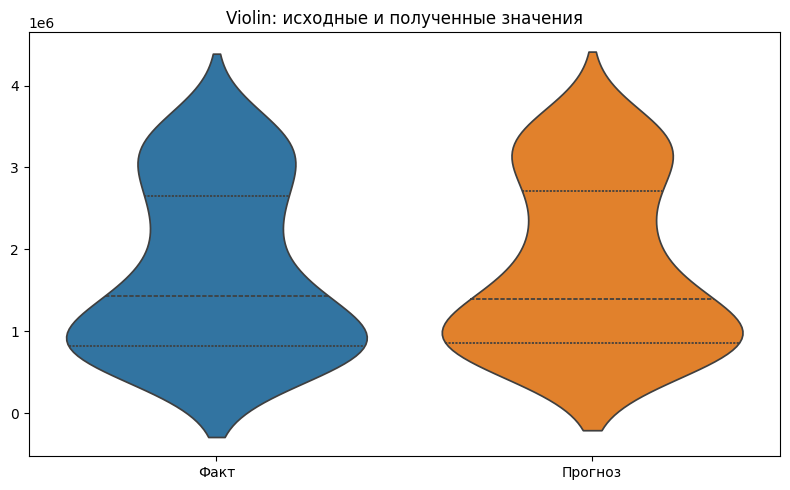

In [ ]:

def mase(y_true, y_pred, y_train, seasonality=1):
    naive = np.mean(np.abs(np.diff(y_train, n=seasonality))) if len(y_train) > seasonality \
            else np.mean(np.abs(y_train - np.mean(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / naive if naive else np.nan

def reg_metrics(y_true, y_pred, y_train, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    mase_v = mase(y_true, y_pred, y_train)
    r2 = r2_score(y_true, y_pred)
    print(f'{name:20s} MAE={mae:,.0f} RMSE={rmse:,.0f} MAPE={mape:.2f}% MASE={mase_v:.3f} R2={r2:.4f}')
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, MASE=mase_v, R2=r2)

reg_results = {}





n_components = min(3, len(feature_cols))




pls_model = PLSRegression(n_components=n_components, scale=False)
pls_model.fit(X_train_l_s, y_train_l)
pred_pls = pls_model.predict(X_test_l_s).ravel()

mae_pls = mean_absolute_error(y_test_l, pred_pls)
rmse_pls = np.sqrt(mean_squared_error(y_test_l, pred_pls))
r2_pls = r2_score(y_test_l, pred_pls)

print(f'PLS (n_components={n_components}):')
print(f'  MAE  = {mae_pls:,.0f}')
print(f'  RMSE = {rmse_pls:,.0f}')
print(f'  R²   = {r2_pls:.4f}')


svr2_model = SVR(kernel='linear', C=100.0, epsilon=0.05)
svr2_model.fit(X_train_s, y_train_s)

pred_svr2 = scaler_y.inverse_transform(
    svr2_model.predict(X_test_s).reshape(-1, 1)).ravel()



best_reg_name = min(reg_results, key=lambda k: reg_results[k]['RMSE'])
best_pred = {'МНК': pred_lr, 'SVR': pred_svr, 'Lasso': pred_lasso}[best_reg_name]
print('\nЛучшая регрессионная модель по RMSE:', best_reg_name)

# График лучшей регрессии
plt.figure(figsize=(14, 5))
plt.plot(test.index, y_test, 'k-', label='Факт')
plt.plot(test.index, best_pred, 'r--', label=f'Прогноз: {best_reg_name}')
plt.title('Лучшая регрессионная модель на тесте')
plt.xlabel('Индекс')
plt.ylabel(VALUE_COL)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Violin-диаграмма факт/прогноз
plt.figure(figsize=(8, 5))
sns.violinplot(data=pd.DataFrame({'Факт': y_test, 'Прогноз': best_pred}), inner='quartile')
plt.title('Violin: исходные и полученные значения')
plt.tight_layout()
plt.show()



Баланс классов:
target
0    0.503268
1    0.496732
Name: proportion, dtype: float64


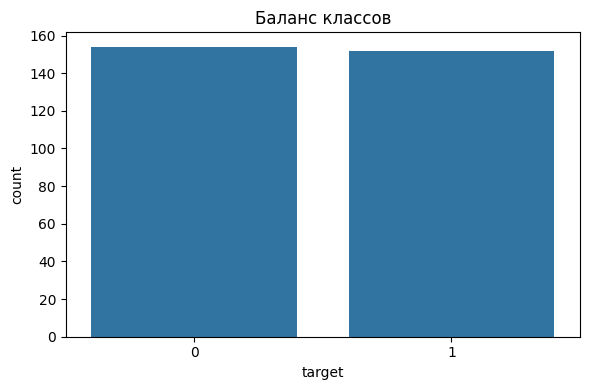


После балансировки обучающей выборки:
target
1    0.52459
0    0.47541
Name: proportion, dtype: float64


In [6]:

data_cls = data.copy()

# Для временных рядов: 1 — рост, 0 — падение
data_cls['target'] = (data_cls['y'] > data_cls['lag_1']).astype(int)

# Если нужен порог для аренды велосипедов:
# THRESHOLD = data_cls['y'].median()   # или экономически выгодное значение
# data_cls['target'] = (data_cls['y'] >= THRESHOLD).astype(int)

print('\nБаланс классов:')
print(data_cls['target'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data_cls)
plt.title('Баланс классов')
plt.tight_layout()
plt.show()

train_cls = data_cls.iloc[:split].copy()
test_cls = data_cls.iloc[split:].copy()

# Балансировка обучающей выборки
def balance_binary(df, target_col='target', random_state=42):
    counts = df[target_col].value_counts()
    if len(counts) < 2:
        return df
    if counts.min() / counts.max() >= 0.8:
        return df
    minority = df[df[target_col] == counts.idxmin()]
    majority = df[df[target_col] == counts.idxmax()]
    majority_down = resample(majority, replace=False, n_samples=len(minority), random_state=random_state)
    return pd.concat([minority, majority_down]).sample(frac=1, random_state=random_state).reset_index(drop=True)

train_cls_bal = balance_binary(train_cls)
print('\nПосле балансировки обучающей выборки:')
print(train_cls_bal['target'].value_counts(normalize=True))

Xc_train = train_cls_bal[feature_cols].values
yc_train = train_cls_bal['target'].values
Xc_test = test_cls[feature_cols].values
yc_test = test_cls['target'].values

scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s = scaler_c.transform(Xc_test)



=== Классификаторы ===
kNN                Acc=0.742 F1=0.652 LogLoss=2.692 ROC-AUC=0.786
SVM                Acc=0.806 F1=0.760 LogLoss=0.492 ROC-AUC=0.852
LogisticRegression Acc=0.758 F1=0.694 LogLoss=0.480 ROC-AUC=0.845
NaiveBayes         Acc=0.645 F1=0.607 LogLoss=0.778 ROC-AUC=0.702
CART               Acc=0.677 F1=0.615 LogLoss=11.627 ROC-AUC=0.675
C4.5               Acc=0.742 F1=0.636 LogLoss=9.302 ROC-AUC=0.713
LDA                Acc=0.806 F1=0.760 LogLoss=0.429 ROC-AUC=0.882

Лучший классификатор по F1: SVM


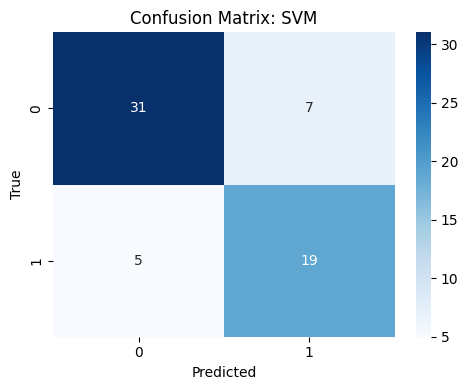

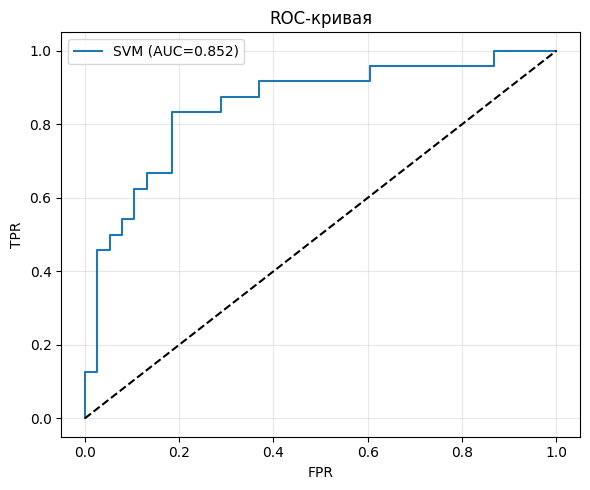

In [7]:

classifiers = {
    'kNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'NaiveBayes': GaussianNB(),
    'CART': DecisionTreeClassifier(random_state=42),
    'C4.5': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

def eval_clf(name, clf, X_tr, y_tr, X_te, y_te):
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    prob = clf.predict_proba(X_te)[:, 1] if hasattr(clf, 'predict_proba') else None
    acc = accuracy_score(y_te, pred)
    f1 = f1_score(y_te, pred)
    ll = log_loss(y_te, prob) if prob is not None else np.nan
    roc = roc_auc_score(y_te, prob) if prob is not None else np.nan
    cm = confusion_matrix(y_te, pred)
    print(f'{name:18s} Acc={acc:.3f} F1={f1:.3f} LogLoss={ll:.3f} ROC-AUC={roc:.3f}')
    return {'model': clf, 'pred': pred, 'prob': prob,
            'acc': acc, 'f1': f1, 'll': ll, 'roc': roc, 'cm': cm}

clf_results = {}
print('\n=== Классификаторы ===')
for name, clf in classifiers.items():
    clf_results[name] = eval_clf(name, clf, Xc_train_s, yc_train, Xc_test_s, yc_test)

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['f1'])
print('\nЛучший классификатор по F1:', best_clf_name)

# Confusion matrix лучшего классификатора
cm = clf_results[best_clf_name]['cm']
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_clf_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# ROC-кривая лучшего классификатора
if clf_results[best_clf_name]['prob'] is not None:
    fpr, tpr, _ = roc_curve(yc_test, clf_results[best_clf_name]['prob'])
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'{best_clf_name} (AUC={clf_results[best_clf_name]["roc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-кривая')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [8]:

prev_y = test_cls['lag_1'].values
pred_growth = (best_pred > prev_y).astype(int)
true_growth = yc_test

acc_reg_cls = accuracy_score(true_growth, pred_growth)
f1_reg_cls = f1_score(true_growth, pred_growth)

score = best_pred - prev_y
prob_reg = 1 / (1 + np.exp(-score / (np.std(score) + 1e-9)))
ll_reg = log_loss(true_growth, prob_reg)
roc_reg = roc_auc_score(true_growth, score)

print('\n=== Классификация на основе лучшей регрессии ===')
print(f'Accuracy={acc_reg_cls:.3f}  F1={f1_reg_cls:.3f}  LogLoss={ll_reg:.3f}  ROC-AUC={roc_reg:.3f}')
print(classification_report(true_growth, pred_growth))



=== Классификация на основе лучшей регрессии ===
Accuracy=0.790  F1=0.787  LogLoss=0.533  ROC-AUC=0.896
              precision    recall  f1-score   support

           0       1.00      0.66      0.79        38
           1       0.65      1.00      0.79        24

    accuracy                           0.79        62
   macro avg       0.82      0.83      0.79        62
weighted avg       0.86      0.79      0.79        62



In [9]:

summary_clf = pd.DataFrame({
    name: {'Accuracy': r['acc'], 'F1': r['f1'], 'LogLoss': r['ll'], 'ROC-AUC': r['roc']}
    for name, r in clf_results.items()
}).T.sort_values('F1', ascending=False)

print('\n=== Сравнение классификаторов ===')
print(summary_clf.round(4).to_string())

print('\n=== Перевод регрессии в классификацию ===')
print(pd.DataFrame({
    'RegressionToClass': {
        'Accuracy': acc_reg_cls,
        'F1': f1_reg_cls,
        'LogLoss': ll_reg,
        'ROC-AUC': roc_reg
    }
}).round(4).to_string())


=== Сравнение классификаторов ===
                    Accuracy      F1  LogLoss  ROC-AUC
SVM                   0.8065  0.7600   0.4925   0.8520
LDA                   0.8065  0.7600   0.4286   0.8816
LogisticRegression    0.7581  0.6939   0.4802   0.8454
kNN                   0.7419  0.6522   2.6917   0.7862
C4.5                  0.7419  0.6364   9.3016   0.7127
CART                  0.6774  0.6154  11.6270   0.6754
NaiveBayes            0.6452  0.6071   0.7780   0.7018

=== Перевод регрессии в классификацию ===
          RegressionToClass
Accuracy             0.7903
F1                   0.7869
LogLoss              0.5326
ROC-AUC              0.8958
